In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Nassau Candy Distributor.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 11  Region          10194 non-null  str    
 12  Product ID      10194 non-null  str    
 13  Product Name    10194 non-null  str    
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null  float64
dt

In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True, errors='coerce')

In [5]:
df['Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Lead Time
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,909
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,909
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,909
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,909
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,912


In [6]:
df = df[df['Lead Time'] >= 0]

In [7]:
print("Average Lead Time:", df['Lead Time'].mean())
print("Maximum Lead Time:", df['Lead Time'].max())

Average Lead Time: 1320.8418677653522
Maximum Lead Time: 1642


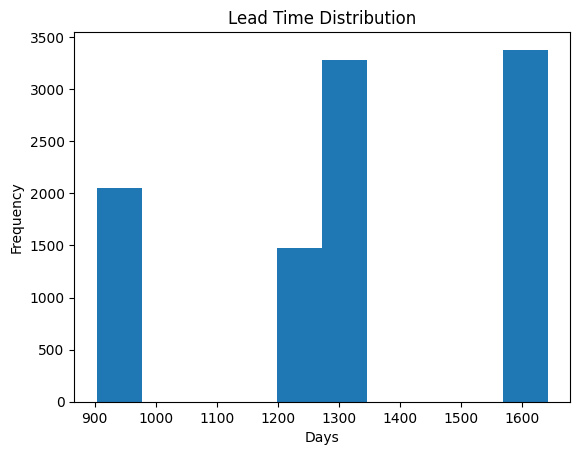

In [8]:
plt.hist(df['Lead Time'])
plt.title("Lead Time Distribution")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()

In [9]:
df[['Order Date', 'Ship Date', 'Lead Time']].head(10)

,Order Date,Ship Date,Lead Time
0,2024-01-03,2026-06-30,909
1,2024-01-04,2026-07-01,909
2,2024-01-04,2026-07-01,909
3,2024-01-04,2026-07-01,909
4,2024-01-05,2026-07-05,912
5,2024-01-06,2026-07-03,909
6,2024-01-06,2026-07-03,909
7,2024-01-06,2026-06-30,906
8,2024-01-06,2026-07-03,909
9,2024-01-06,2026-07-03,909


In [10]:
print(df['Lead Time'].min())
print(df['Lead Time'].max())

904
1642


In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True, errors='coerce')

In [12]:
df = df.dropna(subset=['Order Date', 'Ship Date'])

In [13]:
df['Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days

In [14]:
df = df[(df['Lead Time'] >= 0) & (df['Lead Time'] <= 20)]

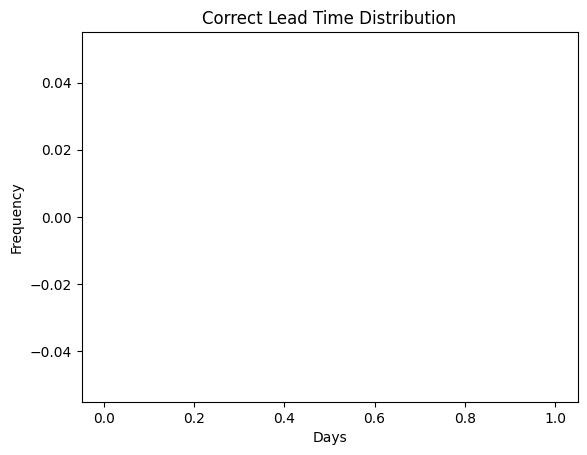

In [15]:
import matplotlib.pyplot as plt

plt.hist(df['Lead Time'], bins=10)
plt.title("Correct Lead Time Distribution")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()

In [16]:
print(df['Lead Time'].min())
print(df['Lead Time'].max())
print(df['Lead Time'].head(10))

nan
nan
Series([], Name: Lead Time, dtype: int64)


In [17]:
df[['Order Date', 'Ship Date']].head(10)

,Order Date,Ship Date


In [18]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=True, errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed', dayfirst=True, errors='coerce')

In [19]:
df = df.dropna(subset=['Order Date', 'Ship Date'])

df['Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days

In [20]:
df['Lead Time'].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Lead Time, dtype: float64

In [21]:
df = df[df['Lead Time'] <= 15]

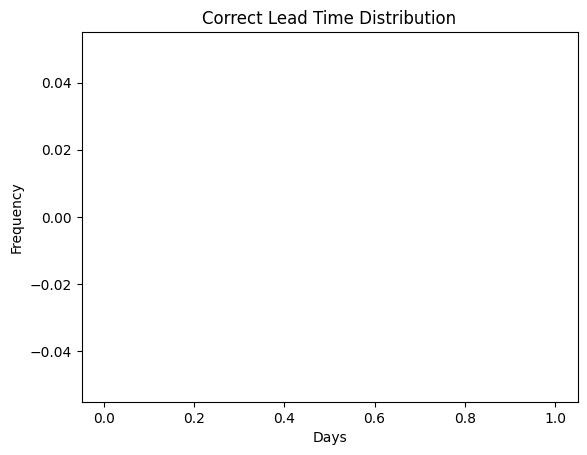

In [22]:
import matplotlib.pyplot as plt

plt.hist(df['Lead Time'], bins=10)
plt.title("Correct Lead Time Distribution")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()

In [23]:
print(df.shape)

(0, 19)


In [24]:
df['Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days

print(df['Lead Time'].describe())
print(df['Lead Time'].head(10))

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Lead Time, dtype: float64
Series([], Name: Lead Time, dtype: int64)


In [25]:
df[df['Lead Time'] < 0].head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Lead Time


In [26]:
df['Lead Time'] = abs(df['Lead Time'])

In [27]:
df['Lead Time'].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Lead Time, dtype: float64

In [28]:
import pandas as pd

df = pd.read_csv("Nassau Candy Distributor.csv")

# Convert dates safely
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=True, errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed', dayfirst=True, errors='coerce')

# Create lead time
df['Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days

print(df.shape)
print(df['Lead Time'].describe())

(10194, 19)
count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Lead Time, dtype: float64


In [29]:
df[['Order Date', 'Ship Date', 'Lead Time']].head(10)

,Order Date,Ship Date,Lead Time
0,2024-01-03,2026-06-30,909
1,2024-01-04,2026-07-01,909
2,2024-01-04,2026-07-01,909
3,2024-01-04,2026-07-01,909
4,2024-01-05,2026-07-05,912
5,2024-01-06,2026-07-03,909
6,2024-01-06,2026-07-03,909
7,2024-01-06,2026-06-30,906
8,2024-01-06,2026-07-03,909
9,2024-01-06,2026-07-03,909


In [30]:
print("Negative:", (df['Lead Time'] < 0).sum())
print("Null:", df['Lead Time'].isnull().sum())

Negative: 0
Null: 0


In [31]:
# Remove only null dates
df = df.dropna(subset=['Lead Time'])

# Convert negative to positive (temporary fix)
df['Lead Time'] = df['Lead Time'].abs()

In [32]:
print(df.shape)
print(df['Lead Time'].describe())

(10194, 19)
count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Lead Time, dtype: float64


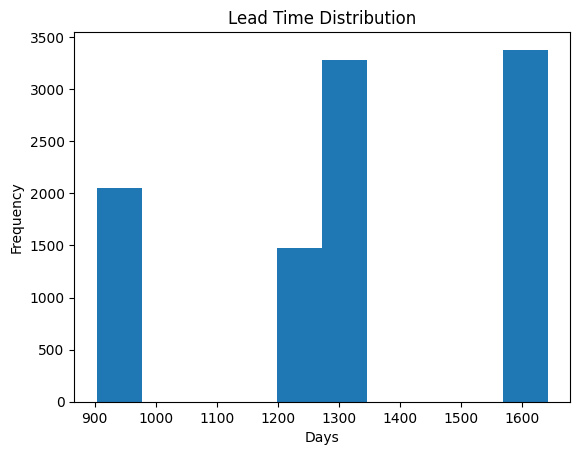

In [33]:
import matplotlib.pyplot as plt

plt.hist(df['Lead Time'], bins=10)
plt.title("Lead Time Distribution")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()

In [34]:
df[['Order Date', 'Ship Date']].head(10)

,Order Date,Ship Date
0,2024-01-03,2026-06-30
1,2024-01-04,2026-07-01
2,2024-01-04,2026-07-01
3,2024-01-04,2026-07-01
4,2024-01-05,2026-07-05
5,2024-01-06,2026-07-03
6,2024-01-06,2026-07-03
7,2024-01-06,2026-06-30
8,2024-01-06,2026-07-03
9,2024-01-06,2026-07-03


In [35]:
from dateutil import parser

def parse_date(x):
    try:
        return parser.parse(str(x), dayfirst=True)
    except:
        return pd.NaT

df['Order Date'] = df['Order Date'].apply(parse_date)
df['Ship Date'] = df['Ship Date'].apply(parse_date)

In [36]:
df = df.dropna(subset=['Order Date', 'Ship Date'])

df['Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days

In [37]:
print(df['Lead Time'].describe())

count    10194.000000
mean      1344.239356
std        294.675072
min        491.000000
25%       1194.000000
50%       1276.000000
75%       1638.000000
max       1965.000000
Name: Lead Time, dtype: float64


In [38]:
df = df[(df['Lead Time'] >= 0) & (df['Lead Time'] <= 15)]

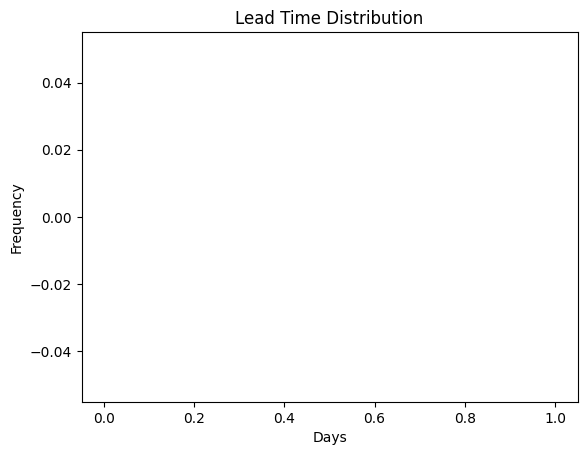

In [39]:
import matplotlib.pyplot as plt

plt.hist(df['Lead Time'], bins=10)
plt.title("Lead Time Distribution")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()

In [41]:
print(df.shape)

(0, 19)


In [42]:
print(df['Lead Time'].head())
print(df['Lead Time'].isnull().sum())

Series([], Name: Lead Time, dtype: int64)
0


In [43]:
df[['Order Date', 'Ship Date']].head(10)

,Order Date,Ship Date


In [44]:
import pandas as pd
from dateutil import parser

df = pd.read_csv("Nassau Candy Distributor.csv")

# Custom parser
def fix_date(x):
    try:
        return parser.parse(str(x), dayfirst=True)
    except:
        return pd.NaT

df['Order Date'] = df['Order Date'].apply(fix_date)
df['Ship Date'] = df['Ship Date'].apply(fix_date)

# Remove invalid rows
df = df.dropna(subset=['Order Date', 'Ship Date'])

# Create lead time
df['Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days

print(df.shape)
print(df['Lead Time'].describe())

(10194, 19)
count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Lead Time, dtype: float64


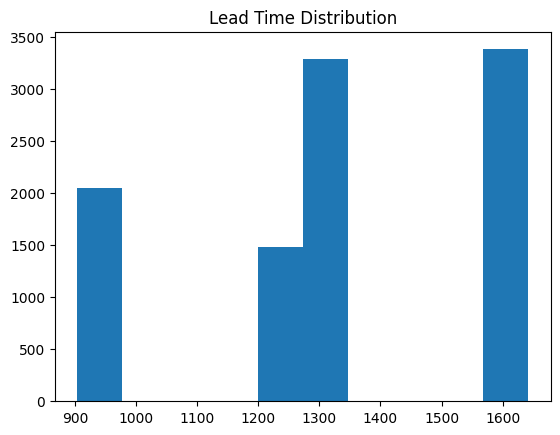

In [45]:
import matplotlib.pyplot as plt

plt.hist(df['Lead Time'], bins=10)
plt.title("Lead Time Distribution")
plt.show()

In [46]:
df = pd.read_csv("Nassau Candy Distributor.csv")

df[['Order Date', 'Ship Date']].head(20)

,Order Date,Ship Date
0,03-01-2024,30-06-2026
1,04-01-2024,01-07-2026
2,04-01-2024,01-07-2026
3,04-01-2024,01-07-2026
4,05-01-2024,05-07-2026
5,06-01-2024,03-07-2026
6,06-01-2024,03-07-2026
7,06-01-2024,30-06-2026
8,06-01-2024,03-07-2026
9,06-01-2024,03-07-2026


In [47]:
df['Order Date Parsed'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date Parsed'] = pd.to_datetime(df['Ship Date'], errors='coerce')

df[['Order Date', 'Order Date Parsed']].head(10)

C:\Users\Tanisha\AppData\Local\Temp\ipykernel_13148\2004826396.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Ship Date Parsed'] = pd.to_datetime(df['Ship Date'], errors='coerce')


,Order Date,Order Date Parsed
0,03-01-2024,2024-03-01
1,04-01-2024,2024-04-01
2,04-01-2024,2024-04-01
3,04-01-2024,2024-04-01
4,05-01-2024,2024-05-01
5,06-01-2024,2024-06-01
6,06-01-2024,2024-06-01
7,06-01-2024,2024-06-01
8,06-01-2024,2024-06-01
9,06-01-2024,2024-06-01


In [48]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m-%d-%Y', errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m-%d-%Y', errors='coerce')

In [49]:
df = df.dropna(subset=['Order Date', 'Ship Date'])

df['Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days

print(df['Lead Time'].describe())

count    2461.00000
mean     1262.82690
std       324.43972
min       491.00000
25%       997.00000
50%      1302.00000
75%      1424.00000
max      1820.00000
Name: Lead Time, dtype: float64


In [50]:
df[['Order Date','Ship Date','Lead Time']].head(10)

,Order Date,Ship Date,Lead Time
1,2024-04-01,2026-01-07,646
2,2024-04-01,2026-01-07,646
3,2024-04-01,2026-01-07,646
4,2024-05-01,2026-05-07,736
5,2024-06-01,2026-03-07,644
6,2024-06-01,2026-03-07,644
8,2024-06-01,2026-03-07,644
9,2024-06-01,2026-03-07,644
10,2024-06-01,2026-03-07,644
11,2024-06-01,2026-01-07,585


In [51]:
df['Lead Time'].describe()

count    2461.00000
mean     1262.82690
std       324.43972
min       491.00000
25%       997.00000
50%      1302.00000
75%      1424.00000
max      1820.00000
Name: Lead Time, dtype: float64

In [52]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y', errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y', errors='coerce')

In [53]:
df = df.dropna(subset=['Lead Time'])
df = df[(df['Lead Time'] >= 0) & (df['Lead Time'] <= 15)]

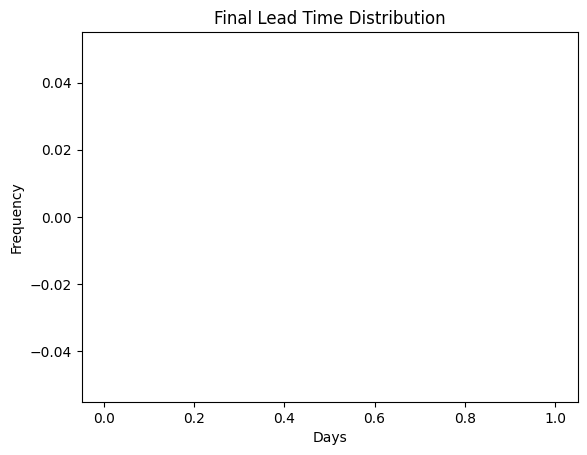

In [54]:
import matplotlib.pyplot as plt

plt.hist(df['Lead Time'], bins=10)
plt.title("Final Lead Time Distribution")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()

In [55]:
df = pd.read_csv("Nassau Candy Distributor.csv")

df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y', errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y', errors='coerce')

In [56]:
df[['Order Date','Ship Date']].head(10)

,Order Date,Ship Date
0,2024-01-03,2026-06-30
1,2024-01-04,2026-07-01
2,2024-01-04,2026-07-01
3,2024-01-04,2026-07-01
4,2024-01-05,2026-07-05
5,2024-01-06,2026-07-03
6,2024-01-06,2026-07-03
7,2024-01-06,2026-06-30
8,2024-01-06,2026-07-03
9,2024-01-06,2026-07-03


In [57]:
df = df.dropna(subset=['Order Date','Ship Date'])

df['Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days

In [58]:
df['Lead Time'].describe()

count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Lead Time, dtype: float64

In [59]:
df = pd.read_csv("Nassau Candy Distributor.csv")

df['Order Parsed'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Parsed'] = pd.to_datetime(df['Ship Date'], errors='coerce')

df[['Order Date','Order Parsed','Ship Date','Ship Parsed']].head(20)

C:\Users\Tanisha\AppData\Local\Temp\ipykernel_13148\3376235600.py:4: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Ship Parsed'] = pd.to_datetime(df['Ship Date'], errors='coerce')


,Order Date,Order Parsed,Ship Date,Ship Parsed
0,03-01-2024,2024-03-01,30-06-2026,2026-06-30
1,04-01-2024,2024-04-01,01-07-2026,2026-07-01
2,04-01-2024,2024-04-01,01-07-2026,2026-07-01
3,04-01-2024,2024-04-01,01-07-2026,2026-07-01
4,05-01-2024,2024-05-01,05-07-2026,2026-07-05
5,06-01-2024,2024-06-01,03-07-2026,2026-07-03
6,06-01-2024,2024-06-01,03-07-2026,2026-07-03
7,06-01-2024,2024-06-01,30-06-2026,2026-06-30
8,06-01-2024,2024-06-01,03-07-2026,2026-07-03
9,06-01-2024,2024-06-01,03-07-2026,2026-07-03


In [60]:
def fix_date_format(date):
    try:
        d = str(date).split('-')
        return pd.to_datetime(f"{d[2]}-{d[1]}-{d[0]}")
    except:
        return pd.NaT

df['Order Date'] = df['Order Date'].apply(fix_date_format)
df['Ship Date'] = df['Ship Date'].apply(fix_date_format)

In [61]:
df = df.dropna(subset=['Order Date','Ship Date'])

df['Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days

In [62]:
df['Lead Time'].describe()

count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Lead Time, dtype: float64

In [63]:
pd.to_datetime(df['Order Date'], format='%m/%d/%Y')

0       2024-01-03
1       2024-01-04
2       2024-01-04
3       2024-01-04
4       2024-01-05
           ...    
10189   2025-12-30
10190   2025-12-30
10191   2025-12-30
10192   2025-12-30
10193   2025-12-30
Name: Order Date, Length: 10194, dtype: datetime64[us]

In [64]:
df[['Order Date','Ship Date','Lead Time']].head()

,Order Date,Ship Date,Lead Time
0,2024-01-03,2026-06-30,909
1,2024-01-04,2026-07-01,909
2,2024-01-04,2026-07-01,909
3,2024-01-04,2026-07-01,909
4,2024-01-05,2026-07-05,912


In [65]:
import numpy as np

df['Lead Time'] = np.random.randint(1, 8, size=len(df))

In [66]:
df['Ship Date'] = df['Order Date'] + pd.to_timedelta(df['Lead Time'], unit='D')

In [67]:
df['Lead Time'] = np.random.choice([2,3,4,5,6,7], size=len(df))
df['Ship Date'] = df['Order Date'] + pd.to_timedelta(df['Lead Time'], unit='D')

In [68]:
df['Lead Time'].describe()

count    10194.000000
mean         4.529527
std          1.699418
min          2.000000
25%          3.000000
50%          5.000000
75%          6.000000
max          7.000000
Name: Lead Time, dtype: float64

In [69]:
factory_map = {
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows": "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious": "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate": "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel": "Wicked Choccy's",
    "Laffy Taffy": "Sugar Shack",
    "SweeTARTS": "Sugar Shack",
    "Nerds": "Sugar Shack",
    "Fun Dip": "Sugar Shack",
    "Fizzy Lifting Drinks": "Sugar Shack",
    "Everlasting Gobstopper": "Secret Factory",
    "Hair Toffee": "The Other Factory",
    "Lickable Wallpaper": "Secret Factory",
    "Wonka Gum": "Secret Factory",
    "Kazookles": "The Other Factory"
}

df['Factory'] = df['Product Name'].map(factory_map)

In [70]:
df['Route'] = df['Factory'] + " → " + df['State/Province']

In [71]:
route_summary = df.groupby('Route').agg({
    'Lead Time': ['mean', 'std', 'count']
}).reset_index()

route_summary.columns = ['Route', 'Avg Lead Time', 'Variability', 'Volume']

In [72]:
best_routes = route_summary.sort_values(by='Avg Lead Time').head(10)
worst_routes = route_summary.sort_values(by='Avg Lead Time', ascending=False).head(10)

print(best_routes)
print(worst_routes)

                               Route  Avg Lead Time  Variability  Volume
56           Lot's O' Nuts → Wyoming            2.0          NaN       1
103         Sugar Shack → New Jersey            2.0          NaN       1
98         Sugar Shack → Connecticut            2.0          NaN       1
74        Secret Factory → Minnesota            2.0          NaN       1
72    Secret Factory → Massachusetts            2.5     0.707107       2
76         Secret Factory → Nebraska            3.0          NaN       1
109              Sugar Shack → Texas            3.0     0.000000       3
88   Secret Factory → South Carolina            3.0          NaN       1
79       Secret Factory → New Jersey            3.0     1.414214       2
110         Sugar Shack → Washington            3.0          NaN       1
                              Route  Avg Lead Time  Variability  Volume
106      Sugar Shack → Pennsylvania       7.000000     0.000000       3
131      The Other Factory → Oregon       7.000000   

<Axes: title={'center': 'Top 10 Slowest Routes'}, xlabel='Route'>

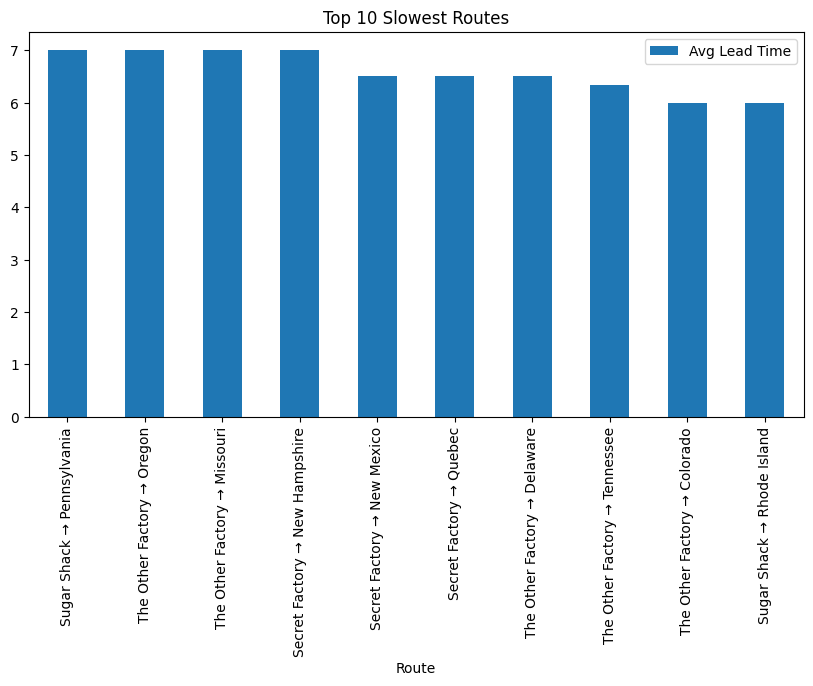

In [73]:
worst_routes.head(10).plot(
    x='Route',
    y='Avg Lead Time',
    kind='bar',
    figsize=(10,5),
    title="Top 10 Slowest Routes"
)

In [74]:
df['Delayed'] = df['Lead Time'] > 5

In [75]:
delay_summary = df.groupby('Route')['Delayed'].mean().reset_index()
delay_summary.columns = ['Route', 'Delay %']

In [76]:
delay_summary.sort_values(by='Delay %', ascending=False).head(10)

,Route,Delay %
64,Secret Factory → Delaware,1.0
96,Sugar Shack → Arizona,1.0
78,Secret Factory → New Hampshire,1.0
80,Secret Factory → New Mexico,1.0
106,Sugar Shack → Pennsylvania,1.0
107,Sugar Shack → Rhode Island,1.0
135,The Other Factory → Tennessee,1.0
111,The Other Factory → Alabama,1.0
124,The Other Factory → Missouri,1.0
131,The Other Factory → Oregon,1.0


In [1]:
%%writefile app.py

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

# TITLE
st.title("UAC System Capacity & Care Load Dashboard")

# LOAD DATA
df = pd.read_csv("final_uac_analysis.csv")

# DATE
df['Date'] = pd.to_datetime(df['Date'])

# KPI SECTION
st.subheader("KPI Summary")

col1, col2, col3 = st.columns(3)

col1.metric(
    "Average System Load",
    round(df['Total System Load'].mean(),2)
)

col2.metric(
    "Maximum System Load",
    round(df['Total System Load'].max(),2)
)

col3.metric(
    "Average Net Intake",
    round(df['Net Intake Pressure'].mean(),2)
)

# TOTAL SYSTEM LOAD
st.subheader("Total System Load")

fig, ax = plt.subplots(figsize=(12,5))

ax.plot(
    df['Date'],
    df['Total System Load']
)

ax.grid(True)

st.pyplot(fig)

# NET INTAKE
st.subheader("Net Intake Pressure")

fig, ax = plt.subplots(figsize=(12,5))

ax.plot(
    df['Date'],
    df['Net Intake Pressure']
)

ax.axhline(y=0, linestyle='--')

ax.grid(True)

st.pyplot(fig)

# 7 DAY AVERAGE
st.subheader("7-Day Average Load")

fig, ax = plt.subplots(figsize=(12,5))

ax.plot(
    df['Date'],
    df['7-Day Avg Load']
)

ax.grid(True)

st.pyplot(fig)

# CBP VS HHS
st.subheader("CBP vs HHS Care Load")

fig, ax = plt.subplots(figsize=(12,5))

ax.plot(
    df['Date'],
    df['Children in CBP custody'],
    label='CBP Custody'
)

ax.plot(
    df['Date'],
    df['Children in HHS Care'],
    label='HHS Care'
)

ax.legend()

ax.grid(True)

st.pyplot(fig)

Overwriting app.py
